# Predictive Marketing Milestone Attribution for Automotive Campaign Optimization

**Project Overview:**  
This notebook builds an end-to-end machine learning workflow to predict whether an automotive marketing touchpoint will achieve a qualified marketing milestone. The project uses Logistic Regression, Random Forest, and Gradient Boosting models to compare performance and generate useful campaign optimization insights.

### Project Outline
1. Data Loading & Preliminary Inspection  
2. Exploratory Data Analysis  
3. Preprocessing & Feature Engineering  
4. Model Training using Logistic Regression, Random Forest, and Gradient Boosting  
5. Model Evaluation & Metrics Comparison  
6. Feature Importance & Business Insights  
7. Marketing Milestone Scoring & Prediction Engine  
8. Model Export and Final Project Completion

## 1. Data Loading & Preliminary Inspection

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve
)

try:
    import joblib
except ImportError:
    joblib = None

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
csv_path = '1778828549471_auto_marketing_01 1(1).csv'
if not os.path.exists(csv_path):
    csv_path = r'C:\Users\jana.sushanth.EXAFLUENCE-INC\Downloads\1778828549471_auto_marketing_01.csv'
df = pd.read_csv(csv_path)

print('Dataset successfully loaded')
print(f'Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\\n Column Names:')
print(df.columns.tolist())
print('\\n Data Types:')
print(df.dtypes)
print('\\n Missing Values:')
print(df.isnull().sum())
print('\\n First 5 Rows:')
df.head()

Dataset successfully loaded
Dimensions: 63,856 rows × 24 columns
\n Column Names:
['campaign_touch_id', 'activity_month', 'vehicle_segment', 'model_year_position', 'powertrain_focus', 'primary_channel', 'secondary_channel_syndicated_flag', 'shopper_intent_decile', 'market_region_tier', 'nameplate_lifecycle_stage', 'incentive_program_pressure_band', 'competitive_conquest_intensity_band', 'days_supply_inventory_proxy_band', 'auto_loan_rate_environment_band', 'personalization_depth_band', 'dealer_cosponsored_local_campaign_flag', 'days_since_last_brand_engagement', 'major_auto_show_or_event_window_flag', 'ev_adoption_maturity_region_band', 'ad_frequency_saturation_risk_band', 'certified_preowned_vs_new_intent_context', 'credit_availability_consumer_stress_band', 'multicultural_locale_creative_match_flag', 'qualified_marketing_milestone_achieved']
\n Data Types:
campaign_touch_id                           object
activity_month                              object
vehicle_segment            

,campaign_touch_id,activity_month,vehicle_segment,model_year_position,powertrain_focus,primary_channel,secondary_channel_syndicated_flag,shopper_intent_decile,market_region_tier,nameplate_lifecycle_stage,incentive_program_pressure_band,competitive_conquest_intensity_band,days_supply_inventory_proxy_band,auto_loan_rate_environment_band,personalization_depth_band,dealer_cosponsored_local_campaign_flag,days_since_last_brand_engagement,major_auto_show_or_event_window_flag,ev_adoption_maturity_region_band,ad_frequency_saturation_risk_band,certified_preowned_vs_new_intent_context,credit_availability_consumer_stress_band,multicultural_locale_creative_match_flag,qualified_marketing_milestone_achieved
0,AMK-00000001,2024-09,Midsize Sedan,Current Model Year,BEV,Email – CRM,No,5,US – Suburban / Secondary,Runout / End of Generation,Light Incentives,Moderate,High – Over 60,Favourable vs Prior Quarter,Generic,No,46,Yes,Growing,Low Exposure,CPO / Used Consideration,Tightening,No,0
1,AMK-00000002,2022-04,Full-Size Pickup,Current Model Year,ICE,Dealer Co-op – Local Digital,Yes,3,US – Major Metro,Runout / End of Generation,Light Incentives,High – New Entrants,Balanced,Adverse – Rising APR,Segmented,No,49,No,Growing,Typical,New Vehicle Focus,Benign,Yes,0
2,AMK-00000003,2022-03,Full-Size Pickup,Current Model Year,ICE,Dealer Co-op – Local Digital,No,7,US – Rural / Exurban,Runout / End of Generation,Moderate APR / Cash,Low,Balanced,Adverse – Rising APR,Generic,No,41,No,Growing,High Fatigue Risk,New Vehicle Focus,Tightening,Yes,0
3,AMK-00000004,2025-09,Midsize Sedan,Current Model Year,Hybrid,Programmatic Video / CTV,Yes,10,US – Major Metro,Steady State,Light Incentives,Low,Tight – Under 30,Flat,Segmented,No,32,No,Growing,Typical,CPO / Used Consideration,Benign,Yes,0
4,AMK-00000005,2024-07,Compact SUV / Crossover,Current Model Year,Hybrid,Paid Search,Yes,4,US – Suburban / Secondary,Steady State,Moderate APR / Cash,Low,Balanced,Adverse – Rising APR,Segmented,No,38,No,Early Market,Typical,CPO / Used Consideration,Benign,Yes,0


In [3]:
print('Statistical Summary:')
df.describe(include='all').T

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
campaign_touch_id,63856,63856,AMK-00063840,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
activity_month,63856,48,2024-07,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_segment,63856,6,Compact SUV / Crossover,17848,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year_position,63856,3,Current Model Year,46031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
powertrain_focus,63856,4,ICE,33388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_channel,63856,7,Paid Social,14153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
secondary_channel_syndicated_flag,63856,2,No,38345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shopper_intent_decile,63856.0,NaN,NaN,NaN,5.49596,2.86769,1.0,3.0,6.0,8.0,10.0
market_region_tier,63856,5,US – Major Metro,21742,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nameplate_lifecycle_stage,63856,4,Steady State,36739,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis (EDA)

In [4]:
target_col = 'qualified_marketing_milestone_achieved'

print('Target Variable Distribution:')
print(df[target_col].value_counts())
print(f"\\nQualified Marketing Milestone Achievement Rate: {df[target_col].mean()*100:.2f}%")

Target Variable Distribution:
qualified_marketing_milestone_achieved
0    48316
1    15540
Name: count, dtype: int64
\nQualified Marketing Milestone Achievement Rate: 24.34%


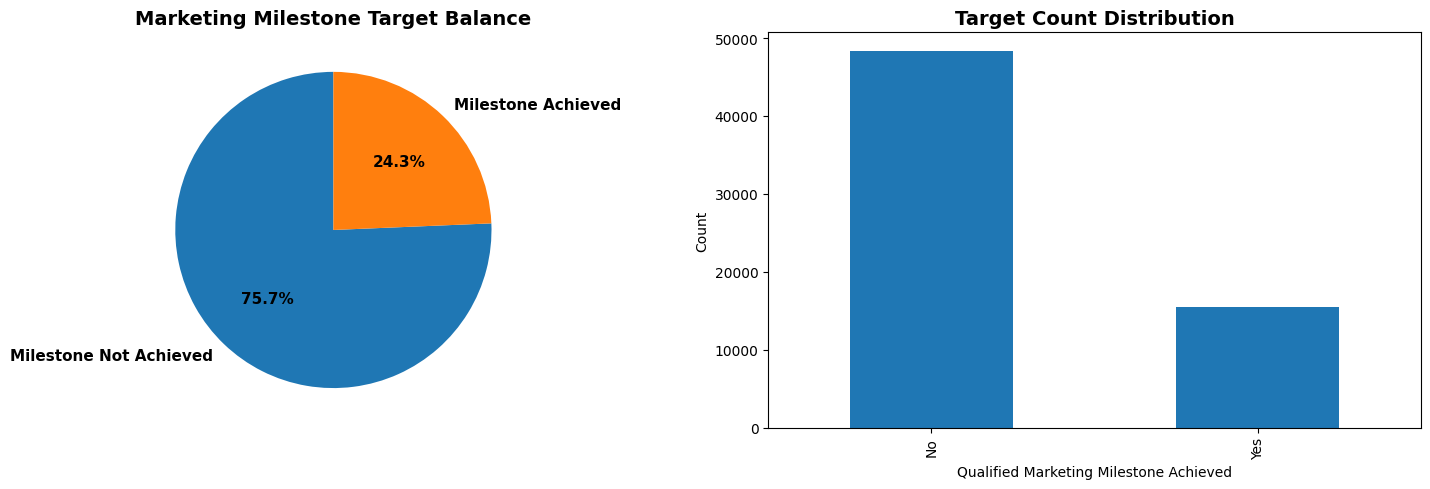

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

target_counts = df[target_col].value_counts().sort_index()
axes[0].pie(
    target_counts.values,
    labels=['Milestone Not Achieved', 'Milestone Achieved'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11, 'weight': 'bold'}
)
axes[0].set_title('Marketing Milestone Target Balance', fontsize=14, fontweight='bold')

target_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Target Count Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Qualified Marketing Milestone Achieved')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

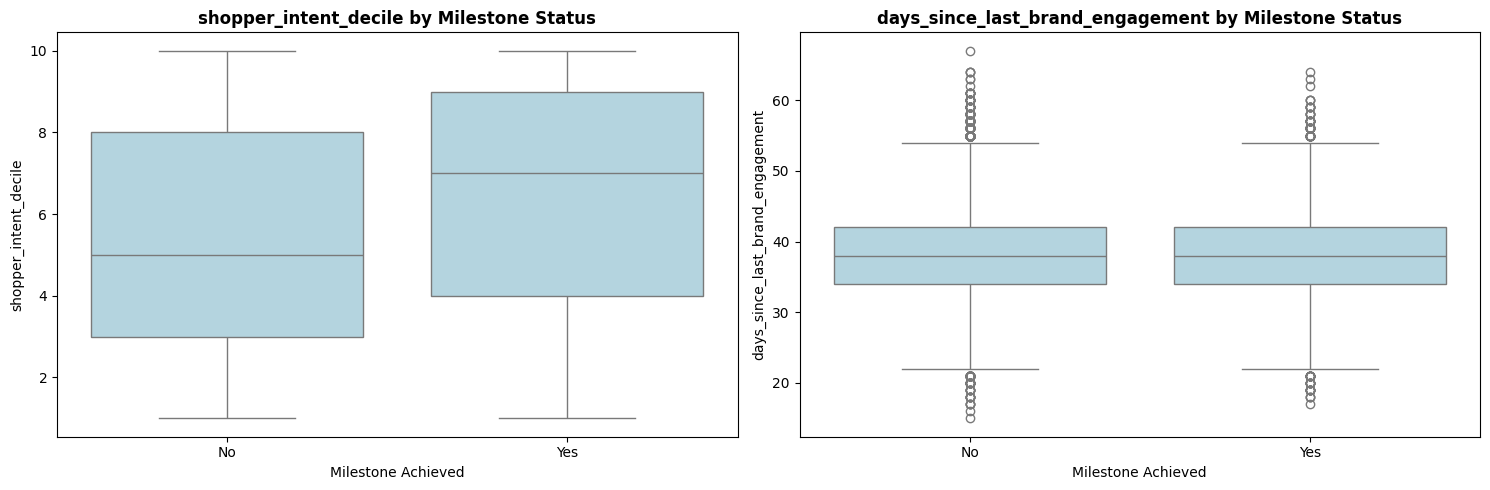

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

numeric_features_to_plot = ['shopper_intent_decile', 'days_since_last_brand_engagement']

for idx, feature in enumerate(numeric_features_to_plot):
    sns.boxplot(x=target_col, y=feature, data=df, ax=axes[idx], color='lightblue')
    axes[idx].set_title(f'{feature} by Milestone Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Milestone Achieved')
    axes[idx].set_xticklabels(['No', 'Yes'])
    axes[idx].set_ylabel(feature)

plt.tight_layout()
plt.show()

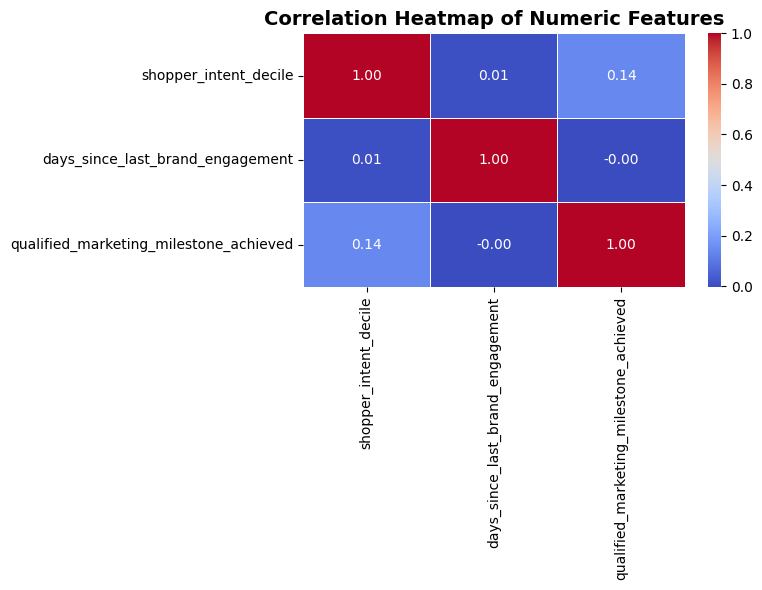

In [7]:
numeric_cols_for_corr = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

plt.figure(figsize=(8, 6))
corr = df[numeric_cols_for_corr].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

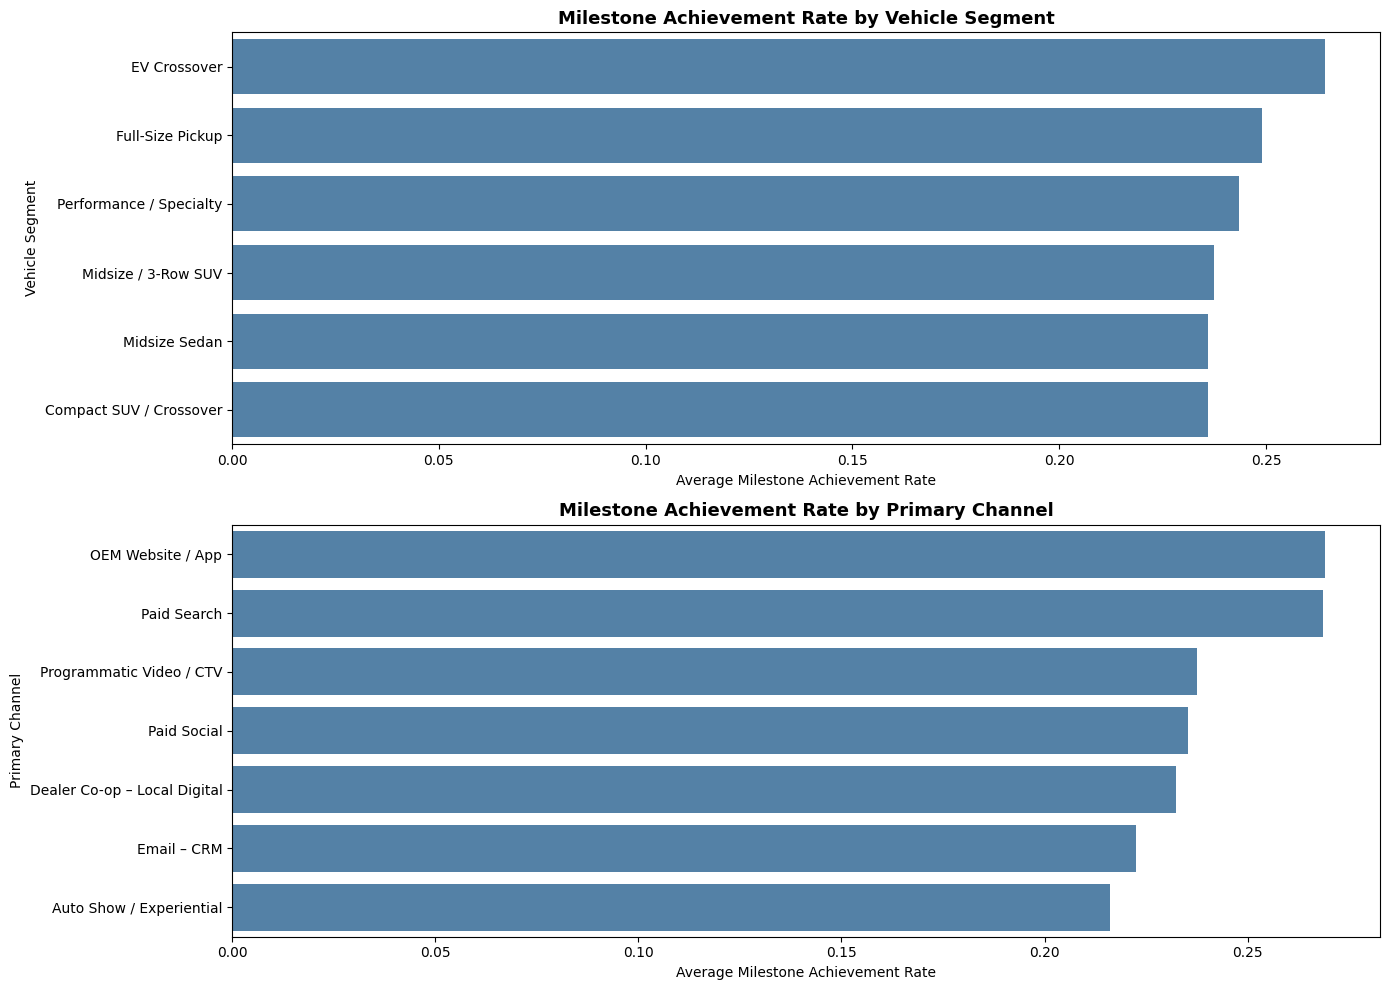

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

segment_rate = df.groupby('vehicle_segment')[target_col].agg(['mean', 'count']).reset_index().sort_values('mean', ascending=False)
sns.barplot(x='mean', y='vehicle_segment', data=segment_rate, ax=axes[0], color='steelblue')
axes[0].set_title('Milestone Achievement Rate by Vehicle Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Milestone Achievement Rate')
axes[0].set_ylabel('Vehicle Segment')

channel_rate = df.groupby('primary_channel')[target_col].agg(['mean', 'count']).reset_index().sort_values('mean', ascending=False)
sns.barplot(x='mean', y='primary_channel', data=channel_rate, ax=axes[1], color='steelblue')
axes[1].set_title('Milestone Achievement Rate by Primary Channel', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Milestone Achievement Rate')
axes[1].set_ylabel('Primary Channel')

plt.tight_layout()
plt.show()

## 3. Preprocessing & Feature Engineering

In [ ]:
df_processed = df.sample(n=min(5000, len(df)), random_state=42).copy()
print(f'Using {len(df_processed):,} records for faster model training and smooth notebook execution.')

print('Applying IQR method for outlier removal on numerical columns...')

col = 'days_since_last_brand_engagement'
q1 = df_processed[col].quantile(0.25)
q3 = df_processed[col].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

initial_shape = df_processed.shape[0]
outliers_df = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)]
df_processed = df_processed[(df_processed[col] >= lower_bound) & (df_processed[col] <= upper_bound)]
final_shape = df_processed.shape[0]

print(f"IQR Outlier Removal on '{col}':")
print(f"  Q1 (25th percentile): {q1:.2f}")
print(f"  Q3 (75th percentile): {q3:.2f}")
print(f"  IQR: {iqr:.2f}")
print(f"  Lower Bound (Q1 - 1.5 * IQR): {lower_bound:.2f}")
print(f"  Upper Bound (Q3 + 1.5 * IQR): {upper_bound:.2f}")
print(f"  Outliers detected and removed: {len(outliers_df)} ({len(outliers_df)/initial_shape*100:.2f}%)")
print(f"  Dataset shape changed from {initial_shape} to {final_shape} records.\n")

print('Engineering useful automotive campaign features...')
df_processed['recent_engagement_flag'] = np.where(df_processed['days_since_last_brand_engagement'] <= 30, 1, 0)
df_processed['high_intent_flag'] = np.where(df_processed['shopper_intent_decile'] >= 8, 1, 0)
df_processed['intent_engagement_score'] = df_processed['shopper_intent_decile'] / (df_processed['days_since_last_brand_engagement'] + 1)

df_processed['activity_month'] = pd.to_datetime(df_processed['activity_month'], errors='coerce')
df_processed['activity_month_num'] = df_processed['activity_month'].dt.month

df_processed = df_processed.drop(columns=['activity_month'])

print('Feature engineering completed')
df_processed.head()

Using 5,000 records for faster model training and smooth notebook execution.
Applying IQR method for outlier removal on numerical columns...
IQR Outlier Removal on 'days_since_last_brand_engagement':
  Q1 (25th percentile): 34.00
  Q3 (75th percentile): 42.00
  IQR: 8.00
  Lower Bound (Q1 - 1.5 * IQR): 22.00
  Upper Bound (Q3 + 1.5 * IQR): 54.00
  Outliers detected and removed: 30 (0.60%)
  Dataset shape changed from 5000 to 4970 records.

Engineering useful automotive campaign features...
Feature engineering completed


,campaign_touch_id,vehicle_segment,model_year_position,powertrain_focus,primary_channel,secondary_channel_syndicated_flag,shopper_intent_decile,market_region_tier,nameplate_lifecycle_stage,incentive_program_pressure_band,competitive_conquest_intensity_band,days_supply_inventory_proxy_band,auto_loan_rate_environment_band,personalization_depth_band,dealer_cosponsored_local_campaign_flag,days_since_last_brand_engagement,major_auto_show_or_event_window_flag,ev_adoption_maturity_region_band,ad_frequency_saturation_risk_band,certified_preowned_vs_new_intent_context,credit_availability_consumer_stress_band,multicultural_locale_creative_match_flag,qualified_marketing_milestone_achieved,recent_engagement_flag,high_intent_flag,intent_engagement_score,activity_month_num
20450,AMK-00020451,Compact SUV / Crossover,Prior Year Closeout,ICE,Paid Social,No,2,US – Suburban / Secondary,Steady State,Heavy Stair-Step Risk,Moderate,Balanced,Favourable vs Prior Quarter,1:1 Next-Best-Offer,Yes,32,No,Growing,Low Exposure,New Vehicle Focus,Tightening,No,0,0,0,0.060606,6
27174,AMK-00027175,Midsize Sedan,Next MY Pre-Order,BEV,Programmatic Video / CTV,No,8,US – Suburban / Secondary,New Launch / Fresh Reveal,Heavy Stair-Step Risk,Low,High – Over 60,Flat,Segmented,No,29,No,Mature EV Penetration,High Fatigue Risk,New Vehicle Focus,Tightening,No,0,1,1,0.266667,8
5931,AMK-00005932,Midsize Sedan,Current Model Year,ICE,Paid Social,Yes,6,Canada,Mid-Cycle Refresh,Light Incentives,Low,Balanced,Adverse – Rising APR,Segmented,Yes,51,No,Growing,Typical,Mixed / Undecided,Tightening,No,0,0,0,0.115385,4
56952,AMK-00056953,EV Crossover,Current Model Year,BEV,Programmatic Video / CTV,No,2,US – Major Metro,Steady State,Moderate APR / Cash,Moderate,High – Over 60,Adverse – Rising APR,Segmented,No,44,No,Growing,Low Exposure,New Vehicle Focus,Tightening,Yes,0,0,0,0.044444,1
32382,AMK-00032383,EV Crossover,Current Model Year,ICE,OEM Website / App,No,10,Canada,Steady State,Heavy Stair-Step Risk,Moderate,Tight – Under 30,Flat,Segmented,Yes,37,No,Mature EV Penetration,Typical,New Vehicle Focus,Benign,Yes,0,0,1,0.263158,7


In [10]:
id_cols = ['campaign_touch_id']
X = df_processed.drop(columns=id_cols + [target_col])
y = df_processed[target_col]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

print('Features Prepared:')
print(f'Numerical features ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Target column: {target_col}')
print(f'Target classes: {sorted(y.unique())}')

Features Prepared:
Numerical features (6): ['shopper_intent_decile', 'days_since_last_brand_engagement', 'recent_engagement_flag', 'high_intent_flag', 'intent_engagement_score', 'activity_month_num']
Categorical features (19): ['vehicle_segment', 'model_year_position', 'powertrain_focus', 'primary_channel', 'secondary_channel_syndicated_flag', 'market_region_tier', 'nameplate_lifecycle_stage', 'incentive_program_pressure_band', 'competitive_conquest_intensity_band', 'days_supply_inventory_proxy_band', 'auto_loan_rate_environment_band', 'personalization_depth_band', 'dealer_cosponsored_local_campaign_flag', 'major_auto_show_or_event_window_flag', 'ev_adoption_maturity_region_band', 'ad_frequency_saturation_risk_band', 'certified_preowned_vs_new_intent_context', 'credit_availability_consumer_stress_band', 'multicultural_locale_creative_match_flag']
Target column: qualified_marketing_milestone_achieved
Target classes: [np.int64(0), np.int64(1)]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Data Split Complete')
print(f'Train set: {X_train.shape[0]:,} samples')
print(f'Test set: {X_test.shape[0]:,} samples')
print(f'Features per sample: {X_train.shape[1]}')
print(f'\\nTrain milestone achievement rate: {y_train.mean()*100:.2f}%')
print(f'Test milestone achievement rate: {y_test.mean()*100:.2f}%')

Data Split Complete
Train set: 3,976 samples
Test set: 994 samples
Features per sample: 25
\nTrain milestone achievement rate: 23.99%
Test milestone achievement rate: 24.04%


In [12]:
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', encoder, categorical_cols)
    ]
)

print('Preprocessing pipeline built successfully')

Preprocessing pipeline built successfully


## 4. Model Training & Comparison

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=80, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=80, learning_rate=0.08, max_depth=3, random_state=42)
}

results = []
trained_pipelines = {}
predictions_dict = {}

for model_name, model in models.items():
    print('\\n' + '='*80)
    print(f'Training {model_name}...')
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4)
    })
    
    trained_pipelines[model_name] = pipeline
    predictions_dict[model_name] = {'pred': y_pred, 'proba': y_pred_proba}
    
    print(f'{model_name} completed')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print(f'ROC-AUC  : {roc:.4f}')

df_results = pd.DataFrame(results)
print('\\n All models trained successfully')

\n================================================================================
Training Logistic Regression...
Logistic Regression completed
Accuracy : 0.6147
Precision: 0.3333
Recall   : 0.6025
F1-Score : 0.4292
ROC-AUC  : 0.6563
\n================================================================================
Training Random Forest...
Random Forest completed
Accuracy : 0.7384
Precision: 0.4071
Recall   : 0.1925
F1-Score : 0.2614
ROC-AUC  : 0.6299
\n================================================================================
Training Gradient Boosting...
Gradient Boosting completed
Accuracy : 0.7555
Precision: 0.3571
Recall   : 0.0209
F1-Score : 0.0395
ROC-AUC  : 0.6427
\n All models trained successfully


### Detailed Evaluation for ALL Models (Logistic Regression, Random Forest, Gradient Boosting)


================ Logistic Regression ================
              precision    recall  f1-score   support

           0     0.8310    0.6185    0.7092       755
           1     0.3333    0.6025    0.4292       239

    accuracy                         0.6147       994
   macro avg     0.5821    0.6105    0.5692       994
weighted avg     0.7113    0.6147    0.6419       994


================ Random Forest ================
              precision    recall  f1-score   support

           0     0.7809    0.9113    0.8411       755
           1     0.4071    0.1925    0.2614       239

    accuracy                         0.7384       994
   macro avg     0.5940    0.5519    0.5512       994
weighted avg     0.6910    0.7384    0.7017       994


================ Gradient Boosting ================
              precision    recall  f1-score   support

           0     0.7612    0.9881    0.8599       755
           1     0.3571    0.0209    0.0395       239

    accuracy             

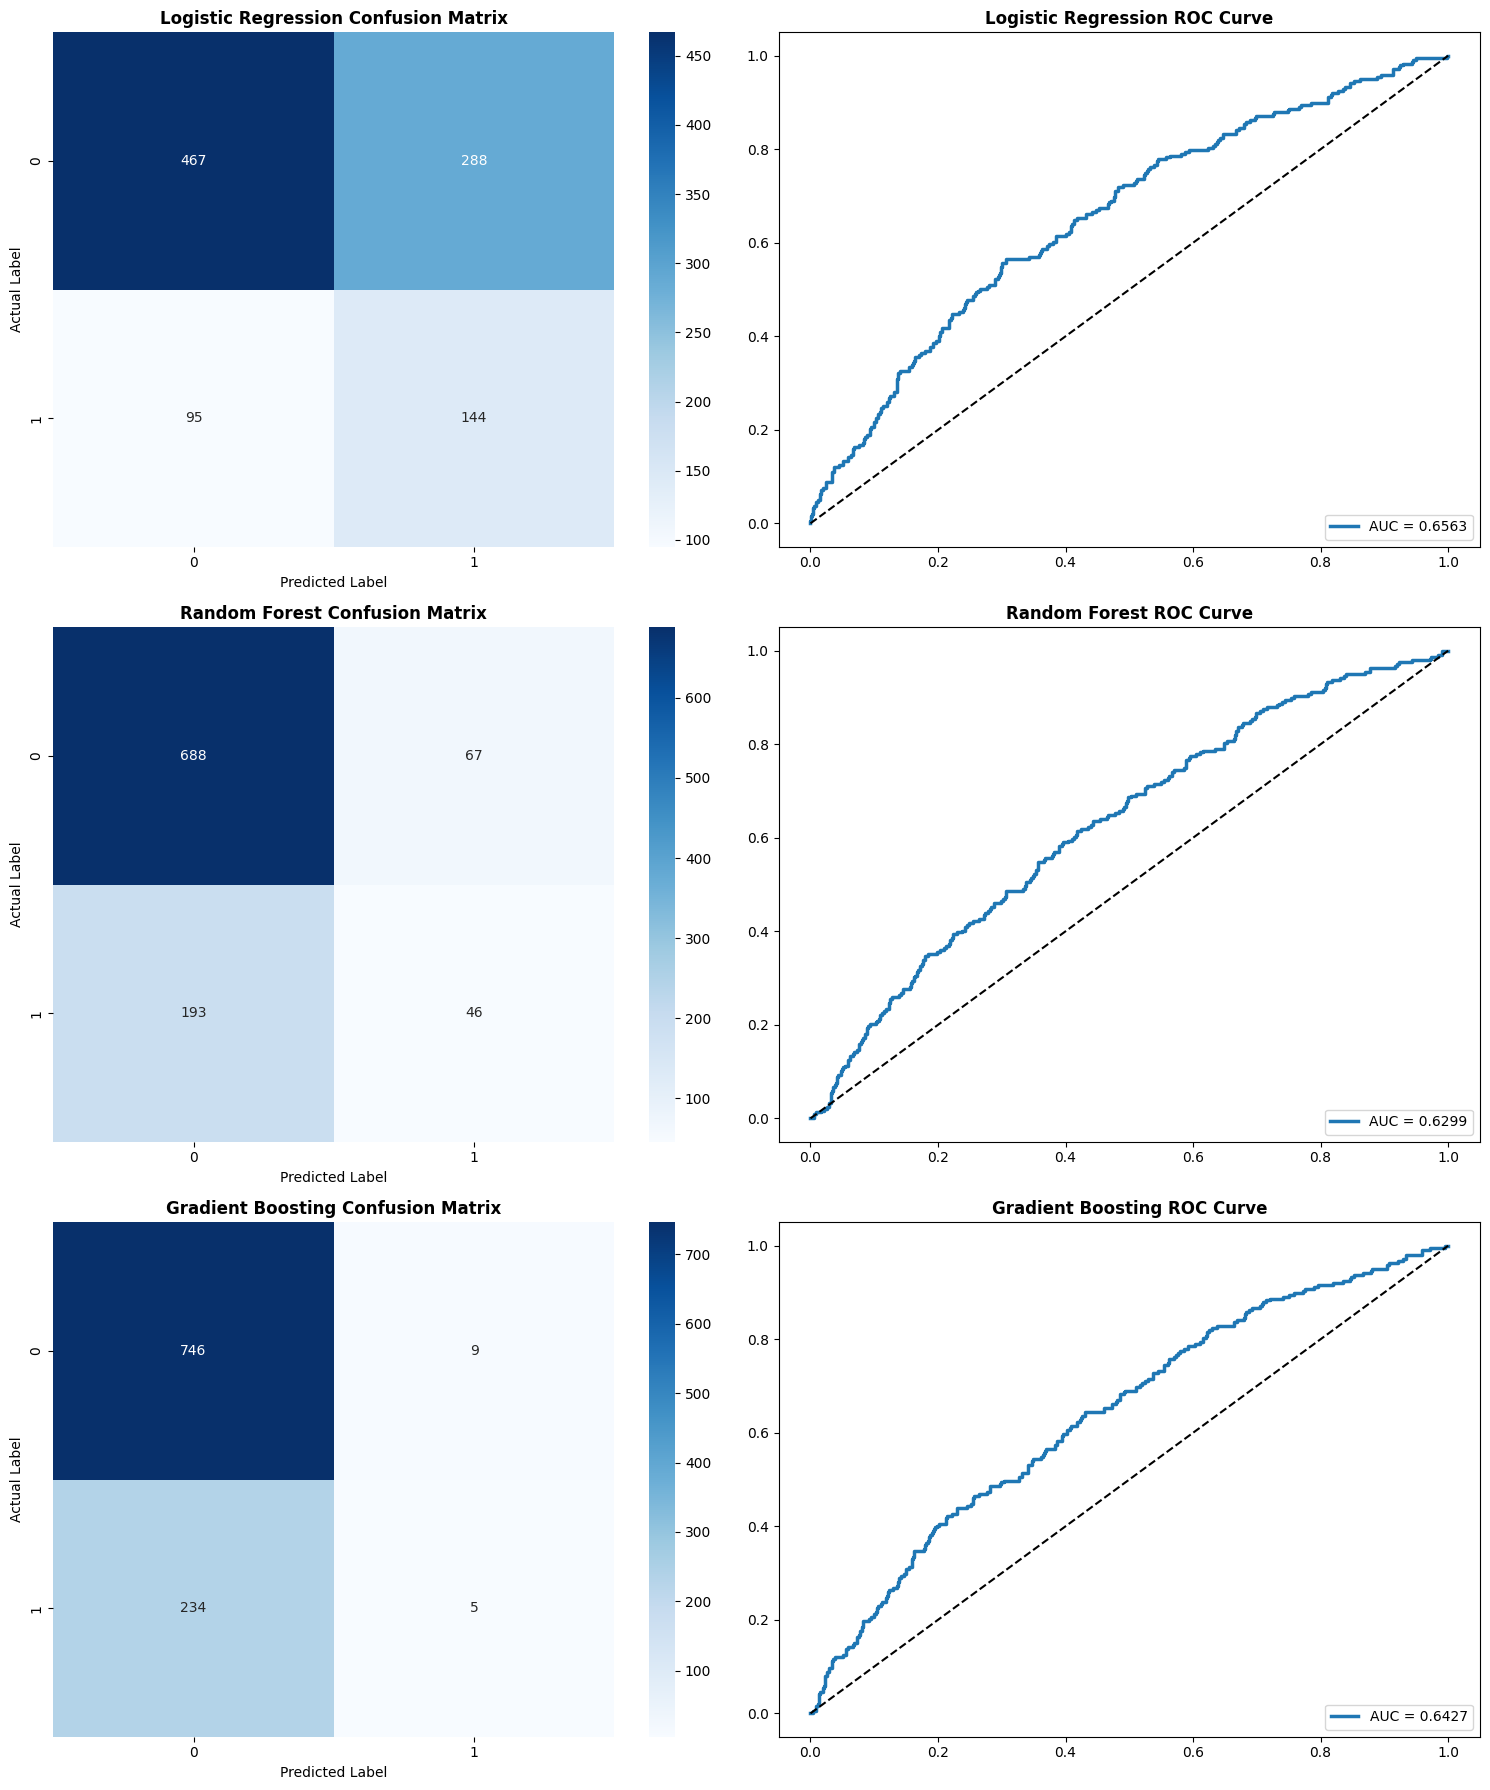

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

fig, axes = plt.subplots(len(predictions_dict), 2, figsize=(15, 6 * len(predictions_dict)))

for idx, (model_name, preds) in enumerate(predictions_dict.items()):
    y_pred_m = preds['pred']
    y_pred_proba_m = preds['proba']
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_m)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0])
    axes[idx, 0].set_title(f'{model_name} Confusion Matrix', fontweight='bold')
    axes[idx, 0].set_ylabel('Actual Label')
    axes[idx, 0].set_xlabel('Predicted Label')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba_m)
    axes[idx, 1].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {roc_auc_score(y_test, y_pred_proba_m):.4f}')
    axes[idx, 1].plot([0, 1], [0, 1], 'k--')
    axes[idx, 1].set_title(f'{model_name} ROC Curve', fontweight='bold')
    axes[idx, 1].legend(loc='lower right')
    
    print(f'\n================ {model_name} ================')
    print(classification_report(y_test, y_pred_m, digits=4))

plt.tight_layout()
plt.show()


## 5. Model Evaluation & Metrics Comparison

In [15]:
print('MODEL PERFORMANCE COMPARISON')
print(df_results.to_string(index=False))

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6147     0.3333  0.6025    0.4292   0.6563
      Random Forest    0.7384     0.4071  0.1925    0.2614   0.6299
  Gradient Boosting    0.7555     0.3571  0.0209    0.0395   0.6427


In [16]:
df_results_numeric = df_results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    df_results_numeric[col] = df_results_numeric[col].astype(float)

champion_name = df_results_numeric.loc[df_results_numeric['ROC-AUC'].idxmax(), 'Model']
champion_roc_auc = df_results_numeric.loc[df_results_numeric['Model'] == champion_name, 'ROC-AUC'].values[0]

print(f'CHAMPION MODEL: {champion_name}')
print(f'ROC-AUC Score: {champion_roc_auc:.4f}')
print('\\nThis model will be used for further analysis and predictions.')

CHAMPION MODEL: Logistic Regression
ROC-AUC Score: 0.6563
\nThis model will be used for further analysis and predictions.


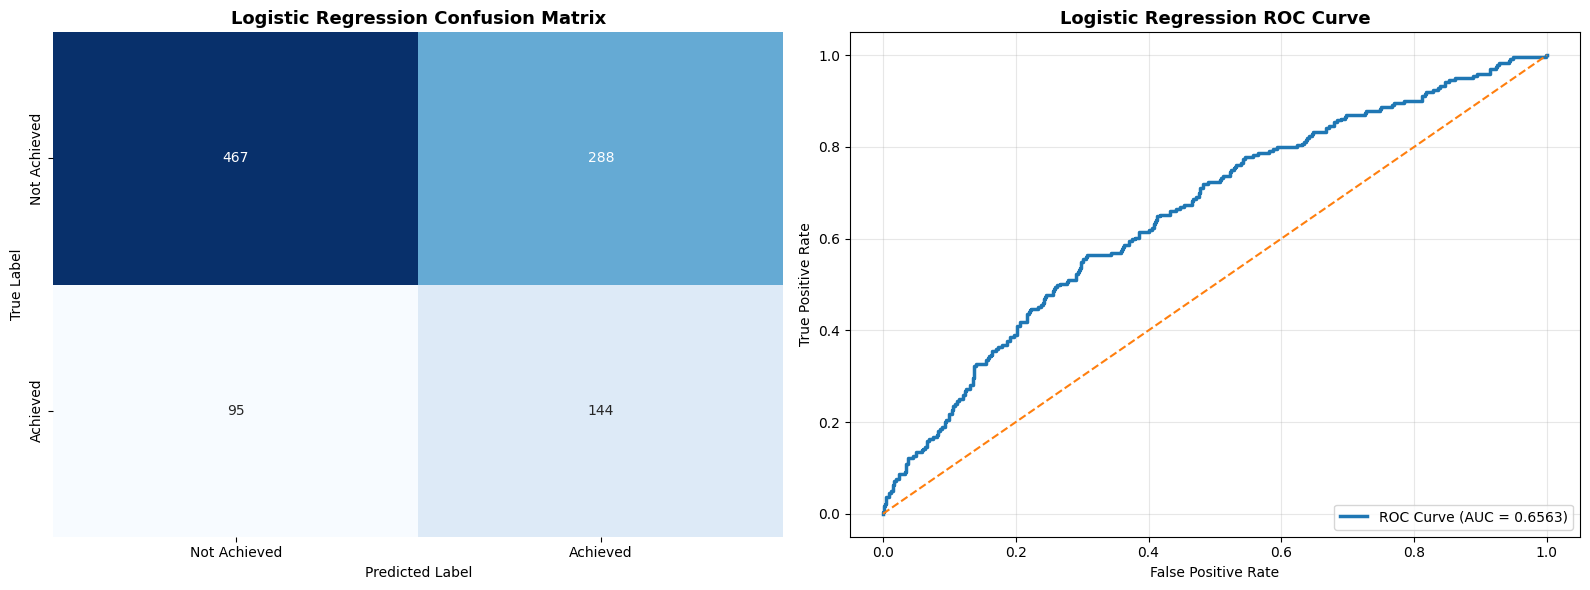

In [17]:
champion_pipeline = trained_pipelines[champion_name]
y_pred = predictions_dict[champion_name]['pred']
y_pred_proba = predictions_dict[champion_name]['proba']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
    xticklabels=['Not Achieved', 'Achieved'],
    yticklabels=['Not Achieved', 'Achieved']
)
axes[0].set_title(f'{champion_name} Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', linewidth=1.5)
axes[1].set_title(f'{champion_name} ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
print(f'DETAILED CLASSIFICATION REPORT - {champion_name}\\n')
print(classification_report(y_test, y_pred, target_names=['Milestone Not Achieved', 'Milestone Achieved'], digits=4))

DETAILED CLASSIFICATION REPORT - Logistic Regression\n
                        precision    recall  f1-score   support

Milestone Not Achieved     0.8310    0.6185    0.7092       755
    Milestone Achieved     0.3333    0.6025    0.4292       239

              accuracy                         0.6147       994
             macro avg     0.5821    0.6105    0.5692       994
          weighted avg     0.7113    0.6147    0.6419       994



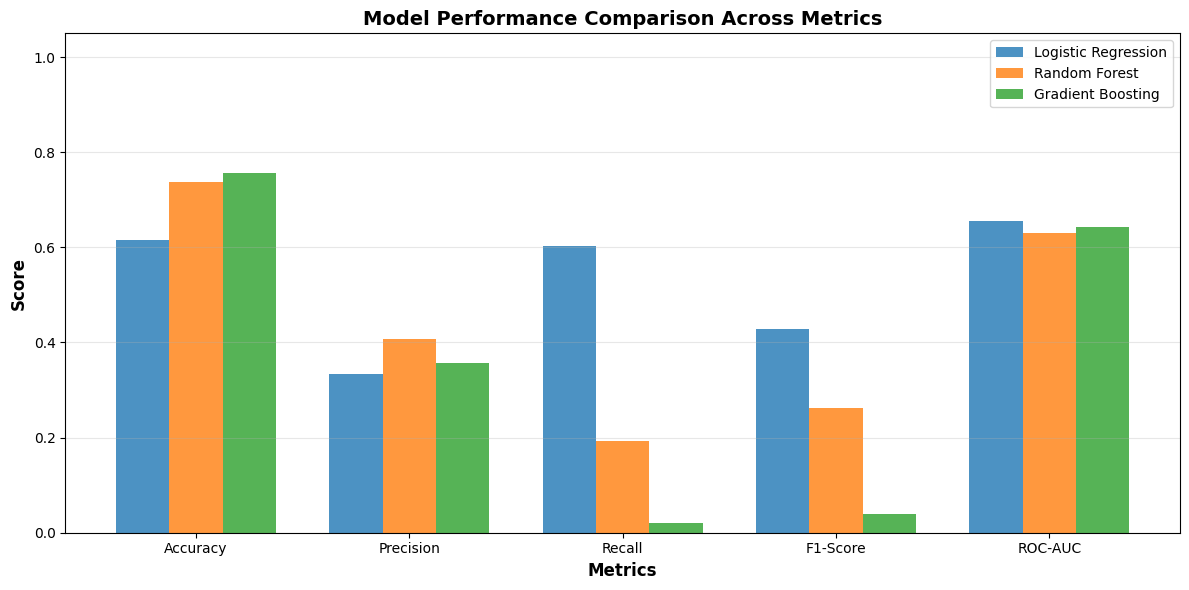

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

for i, model_name in enumerate(df_results_numeric['Model']):
    values = [df_results_numeric.loc[df_results_numeric['Model'] == model_name, m].values[0] for m in metrics]
    ax.bar(x + i*width, values, width, label=model_name, alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison Across Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend(fontsize=10)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Feature Importance & Business Insights

In [20]:
print('Extracting feature importances from Random Forest...')

rf_pipeline = trained_pipelines['Random Forest']
rf_model = rf_pipeline.named_steps['classifier']
preprocessor_obj = rf_pipeline.named_steps['preprocessor']

cat_features_encoded = preprocessor_obj.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_features_encoded

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

df_importance = pd.DataFrame({
    'Feature': [all_feature_names[i] for i in indices],
    'Importance': importances[indices]
})

print('Feature importance extraction complete')
print('\\nTop 20 Most Important Features:')
print(df_importance.head(20).to_string(index=False))

Extracting feature importances from Random Forest...
Feature importance extraction complete
\nTop 20 Most Important Features:
                                             Feature  Importance
                             intent_engagement_score    0.089572
                    days_since_last_brand_engagement    0.065132
                               shopper_intent_decile    0.058036
                                  activity_month_num    0.054855
                                    high_intent_flag    0.030657
 ad_frequency_saturation_risk_band_High Fatigue Risk    0.021583
auto_loan_rate_environment_band_Adverse – Rising APR    0.014605
                  personalization_depth_band_Generic    0.014362
                auto_loan_rate_environment_band_Flat    0.013955
      personalization_depth_band_1:1 Next-Best-Offer    0.013728
           ad_frequency_saturation_risk_band_Typical    0.013703
    incentive_program_pressure_band_Light Incentives    0.013494
      ad_frequency_saturation

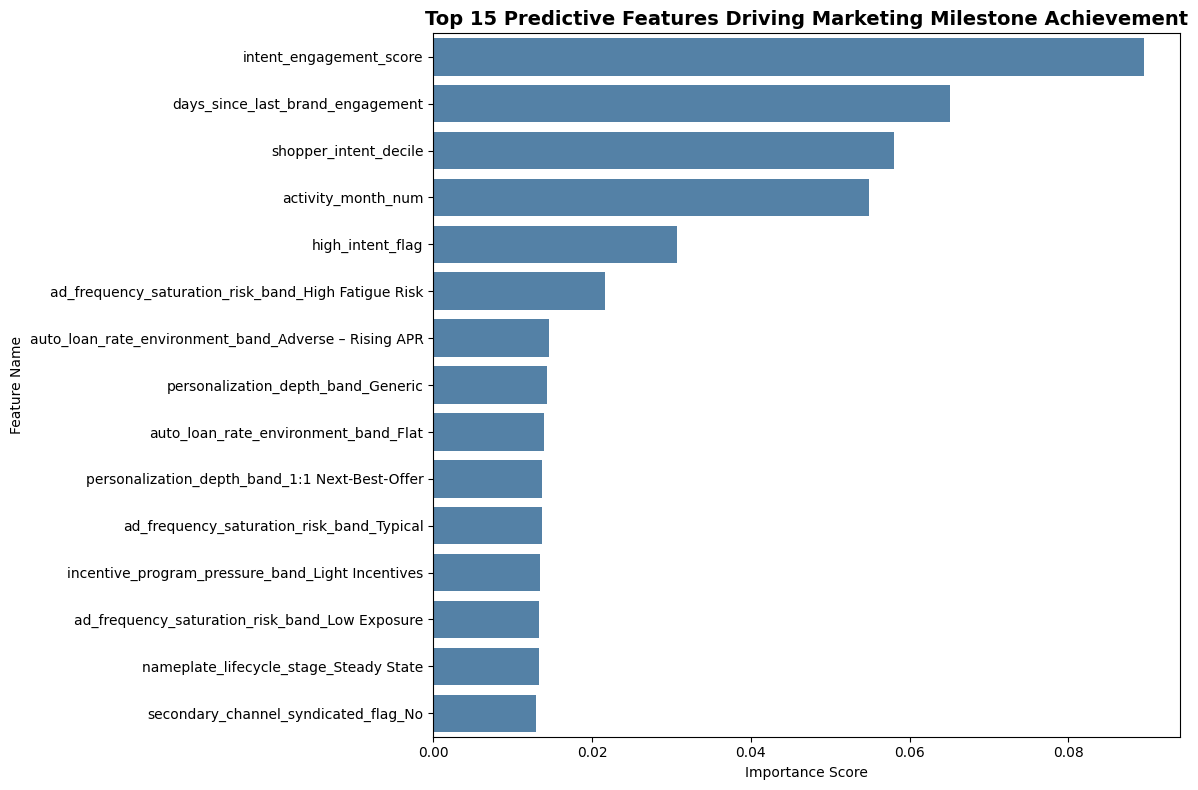

In [21]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(15), color='steelblue')
plt.title('Top 15 Predictive Features Driving Marketing Milestone Achievement', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## 7. Marketing Milestone Scoring & Prediction Engine

In [22]:
scored_df = df_processed.copy()

all_scores = champion_pipeline.predict_proba(X)[:, 1]
all_predictions = champion_pipeline.predict(X)

scored_df['milestone_score'] = all_scores
scored_df['predicted_milestone'] = all_predictions

scored_df['campaign_priority'] = pd.cut(
    scored_df['milestone_score'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Priority', 'Medium Priority', 'High Priority'],
    include_lowest=True
)

print('Campaign Scoring Complete')
print('\\nMilestone Score Distribution:')
print(f"Mean  : {scored_df['milestone_score'].mean():.4f}")
print(f"Median: {scored_df['milestone_score'].median():.4f}")
print(f"Min   : {scored_df['milestone_score'].min():.4f}")
print(f"Max   : {scored_df['milestone_score'].max():.4f}")
print('\\nCampaign Priority Counts:')
print(scored_df['campaign_priority'].value_counts())

Campaign Scoring Complete
\nMilestone Score Distribution:
Mean  : 0.4761
Median: 0.4695
Min   : 0.0864
Max   : 0.8853
\nCampaign Priority Counts:
campaign_priority
Medium Priority    3985
Low Priority        609
High Priority       376
Name: count, dtype: int64


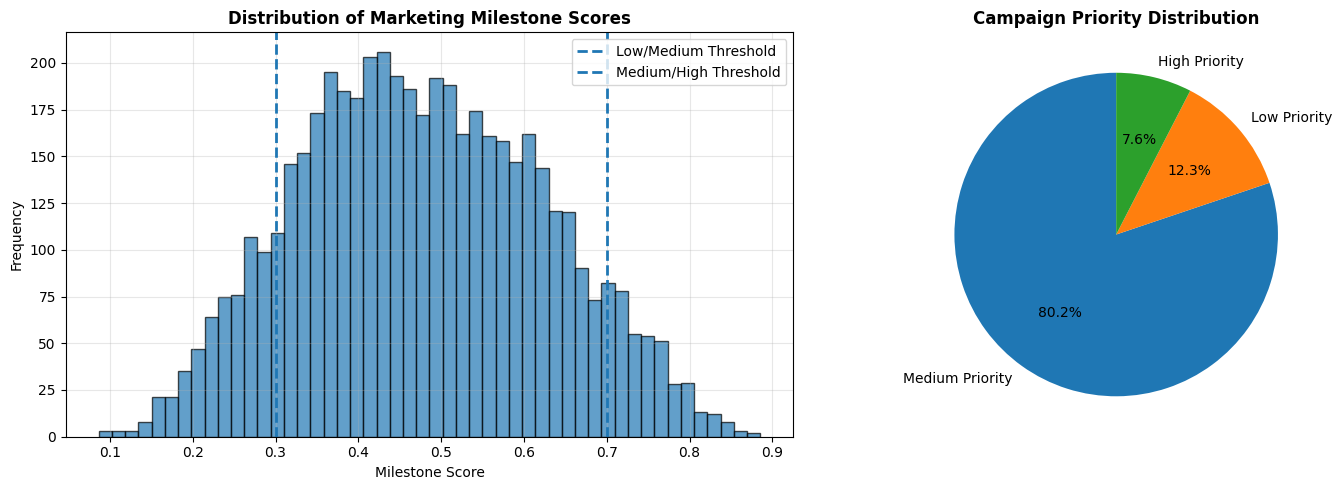

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(scored_df['milestone_score'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0.3, linestyle='--', linewidth=2, label='Low/Medium Threshold')
axes[0].axvline(0.7, linestyle='--', linewidth=2, label='Medium/High Threshold')
axes[0].set_title('Distribution of Marketing Milestone Scores', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Milestone Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

priority_counts = scored_df['campaign_priority'].value_counts()
axes[1].pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Campaign Priority Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
high_priority = scored_df[scored_df['campaign_priority'] == 'High Priority'].sort_values('milestone_score', ascending=False)

print('HIGH PRIORITY CAMPAIGN TOUCHPOINTS - Top 10')
print(f'Total High Priority Touchpoints: {len(high_priority):,}')

display_cols = [
    'campaign_touch_id', 'vehicle_segment', 'primary_channel', 'shopper_intent_decile',
    'days_since_last_brand_engagement', 'milestone_score', 'predicted_milestone'
]
print(high_priority[display_cols].head(10).to_string(index=False))

HIGH PRIORITY CAMPAIGN TOUCHPOINTS - Top 10
Total High Priority Touchpoints: 376
campaign_touch_id         vehicle_segment          primary_channel  shopper_intent_decile  days_since_last_brand_engagement  milestone_score  predicted_milestone
     AMK-00013959 Compact SUV / Crossover Programmatic Video / CTV                     10                                42         0.885330                    1
     AMK-00041041     Midsize / 3-Row SUV              Paid Search                      9                                45         0.875466                    1
     AMK-00062829            EV Crossover              Email – CRM                     10                                39         0.858092                    1
     AMK-00037659     Midsize / 3-Row SUV        OEM Website / App                      8                                44         0.854631                    1
     AMK-00013668        Full-Size Pickup              Email – CRM                     10                    

In [25]:
sample_campaign = X_test.iloc[[0]].copy()

sample_prediction = champion_pipeline.predict(sample_campaign)[0]
sample_probability = champion_pipeline.predict_proba(sample_campaign)[0][1]

print('New Campaign Touchpoint Prediction Completed')
print(f"Prediction: {'Milestone Likely to be Achieved' if sample_prediction == 1 else 'Milestone Not Likely to be Achieved'}")
print(f'Milestone Probability / Score: {sample_probability:.4f}')

if sample_probability >= 0.70:
    priority = 'High Priority'
elif sample_probability >= 0.30:
    priority = 'Medium Priority'
else:
    priority = 'Low Priority'

print(f'Campaign Priority: {priority}')
sample_campaign

New Campaign Touchpoint Prediction Completed
Prediction: Milestone Likely to be Achieved
Milestone Probability / Score: 0.7226
Campaign Priority: High Priority


,vehicle_segment,model_year_position,powertrain_focus,primary_channel,secondary_channel_syndicated_flag,shopper_intent_decile,market_region_tier,nameplate_lifecycle_stage,incentive_program_pressure_band,competitive_conquest_intensity_band,days_supply_inventory_proxy_band,auto_loan_rate_environment_band,personalization_depth_band,dealer_cosponsored_local_campaign_flag,days_since_last_brand_engagement,major_auto_show_or_event_window_flag,ev_adoption_maturity_region_band,ad_frequency_saturation_risk_band,certified_preowned_vs_new_intent_context,credit_availability_consumer_stress_band,multicultural_locale_creative_match_flag,recent_engagement_flag,high_intent_flag,intent_engagement_score,activity_month_num
15147,Full-Size Pickup,Current Model Year,BEV,Paid Search,No,9,US – Major Metro,Mid-Cycle Refresh,Moderate APR / Cash,Low,Tight – Under 30,Flat,Generic,No,36,No,Growing,Low Exposure,CPO / Used Consideration,Tightening,No,0,1,0.243243,11


## 8. Business Recommendations & Strategy

In [26]:
print('\\n' + '='*80)
print('STRATEGIC BUSINESS INSIGHTS & CAMPAIGN RECOMMENDATIONS')
print('='*80)

print('\\n1️ KEY FACTORS DRIVING MARKETING MILESTONE ACHIEVEMENT:')
top_features = df_importance.head(5)
for _, row in top_features.iterrows():
    print(f"   • {row['Feature']}: {row['Importance']*100:.2f}% importance")

print('\\n2️ VEHICLE SEGMENT PERFORMANCE:')
segment_analysis = df.groupby('vehicle_segment')[target_col].agg(['mean', 'count']).sort_values('mean', ascending=False).round(3)
for segment in segment_analysis.index:
    rate = segment_analysis.loc[segment, 'mean'] * 100
    count = int(segment_analysis.loc[segment, 'count'])
    print(f'   • {segment}: {rate:.1f}% milestone achievement ({count:,} records)')

print('\\n3️ PRIMARY CHANNEL EFFECTIVENESS:')
channel_analysis = df.groupby('primary_channel')[target_col].agg(['mean', 'count']).sort_values('mean', ascending=False).round(3)
for channel in channel_analysis.index:
    rate = channel_analysis.loc[channel, 'mean'] * 100
    count = int(channel_analysis.loc[channel, 'count'])
    print(f'   • {channel}: {rate:.1f}% milestone achievement ({count:,} records)')

print('\\n4️ RECOMMENDATIONS:')
print('   • Give more focus to high-score campaign touchpoints.')
print('   • Use the best-performing channels for future campaign budget planning.')
print('   • Prioritize shoppers with stronger intent and recent engagement.')
print('   • Monitor milestone scores regularly and retrain the model when campaign patterns change.')

\n================================================================================
STRATEGIC BUSINESS INSIGHTS & CAMPAIGN RECOMMENDATIONS
\n1️ KEY FACTORS DRIVING MARKETING MILESTONE ACHIEVEMENT:
   • intent_engagement_score: 8.96% importance
   • days_since_last_brand_engagement: 6.51% importance
   • shopper_intent_decile: 5.80% importance
   • activity_month_num: 5.49% importance
   • high_intent_flag: 3.07% importance
\n2️ VEHICLE SEGMENT PERFORMANCE:
   • EV Crossover: 26.4% milestone achievement (10,278 records)
   • Full-Size Pickup: 24.9% milestone achievement (10,168 records)
   • Performance / Specialty: 24.4% milestone achievement (3,798 records)
   • Midsize / 3-Row SUV: 23.7% milestone achievement (14,008 records)
   • Midsize Sedan: 23.6% milestone achievement (7,756 records)
   • Compact SUV / Crossover: 23.6% milestone achievement (17,848 records)
\n3️ PRIMARY CHANNEL EFFECTIVENESS:
   • OEM Website / App: 26.9% milestone achievement (8,870 records)
   • Paid Search: 26

## 9. Model Persistence & Export

In [ ]:
if joblib is not None:
    model_path = 'automotive_champion_model.pkl'
    joblib.dump(champion_pipeline, model_path)
    print(f' Champion model saved: {model_path}')
    
    joblib.dump(champion_pipeline, 'champion_model.pkl')
    print(' Copied to champion_model.pkl for web application usage')
else:
    print(' joblib is not installed, so model file was not saved')

results_path = 'automotive_model_results.csv'
df_results.to_csv(results_path, index=False)
print(f' Model results saved: {results_path}')
df_results.to_csv('model_results.csv', index=False)
print(' Copied to model_results.csv for web application usage')

importance_path = 'automotive_feature_importance.csv'
df_importance.to_csv(importance_path, index=False)
print(f' Feature importance saved: {importance_path}')
df_importance.to_csv('feature_importance.csv', index=False)
print(' Copied to feature_importance.csv for web application usage')

scores_path = 'automotive_campaign_scores.csv'
scored_df[['campaign_touch_id', 'milestone_score', 'predicted_milestone', 'campaign_priority']].to_csv(scores_path, index=False)
print(f' Campaign scores saved: {scores_path}')

 Champion model saved: automotive_champion_model.pkl
 Copied to champion_model.pkl for web application usage
 Model results saved: automotive_model_results.csv
 Copied to model_results.csv for web application usage
 Feature importance saved: automotive_feature_importance.csv
 Copied to feature_importance.csv for web application usage
 Campaign scores saved: automotive_campaign_scores.csv


In [28]:
print('\\n' + '='*80)
print(' PROJECT COMPLETE!')
print('='*80)
print('\\n Output Files Generated:')
print('   1. automotive_champion_model.pkl - Trained ML model for predictions')
print('   2. automotive_model_results.csv - Performance metrics of all models')
print('   3. automotive_feature_importance.csv - Feature importance rankings')
print('   4. automotive_campaign_scores.csv - Campaign touchpoints with milestone scores')
print('\\n Final Output:')
print('   The notebook predicts whether an automotive marketing touchpoint is likely to achieve a qualified marketing milestone.')
print('   It also gives a milestone probability score and campaign priority category.')
print('\\n' + '='*80)

\n================================================================================
 PROJECT COMPLETE!
\n Output Files Generated:
   1. automotive_champion_model.pkl - Trained ML model for predictions
   2. automotive_model_results.csv - Performance metrics of all models
   3. automotive_feature_importance.csv - Feature importance rankings
   4. automotive_campaign_scores.csv - Campaign touchpoints with milestone scores
\n Final Output:
   The notebook predicts whether an automotive marketing touchpoint is likely to achieve a qualified marketing milestone.
   It also gives a milestone probability score and campaign priority category.
\n================================================================================
